# IEEE-14 FDI Attack Analysis

This notebook:

- Loads the IEEE-14 test network.
- Builds a deterministic DC state estimator (WLS).
- Adds Gaussian measurement noise.
- Injects three types of FDI attacks (basic, random, stealth).
- Compares residual-based detection (deterministic vs probabilistic SE).
- Motivates ML-based detection in SGSim for digital substations.

In [1]:
pip install pandapower


[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install seaborn pandas


[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import json
import numpy as np
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import matplotlib.pyplot as plt
import pandapower.plotting.plotly as pplot
import seaborn as sns 

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

In [4]:
import sys
from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))
from src.simulation import load_test_case, build_dc_measurement_model, simulate_measurements
import src.state_estimation
from src.state_estimation import wls_estimate, compute_residuals, state_error
from src.attacks import standard_FDIA, random_attack, stealth_FDIA


### 1 - Load IEEE-9 bus case


In [5]:
# #Load IEEE-14 and run a power flow for an operating point
# net = pn.case14()

# # Run a power flow to get a steady-state solution 
# # And these values act as the "true" system state for later estimation
# pp.runpp(net, algorithm='nr', init='dc', calculate_voltage_angles=True)
# print("Load flow converged:", net.converged)

rng = np.random.default_rng(42)
sigma = 0.04

net = load_test_case("case9")
#net = load_test_case("case14") - switched to IEEE-9 instead of IEEE-14
H, x_true, z_true, mask = build_dc_measurement_model(net)
z_no = simulate_measurements(H, x_true, sigma, rng)

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


### 2 - Build deterministic DC state estimation model (WLS)

In [6]:
# def build_dc_measurement_model(net):
#     """
#     Build a DC state estimation model using branch-flow measurements:

#         z_k = (theta_i - theta_j) / x_ij

#     Returns:
#         H      : measurement matrix (m x n)
#         x_true : true state vector (non-slack angles)
#         z_true : true flow measurements (m,)
#         mask   : boolean mask for non-slack buses
#     """

#     # ---------------------------
#     # 1. Identify slack and true angles
#     # ---------------------------
#     slack_bus = net.ext_grid.bus.values[0]
#     va_deg = net.res_bus.va_degree.values
#     va_rad = np.deg2rad(va_deg)

#     nb = len(net.bus)

#     # Mask of non-slack buses
#     mask = np.ones(nb, dtype=bool)
#     mask[slack_bus] = False
#     non_slack_buses = np.where(mask)[0]
#     n = len(non_slack_buses)

#     # True state vector (angles at non-slack buses)
#     x_true = va_rad[mask]

#     # ---------------------------
#     # 2. Build measurement matrix H (branch flows)
#     # ---------------------------
#     rows = []
#     z_true_list = []

#     for _, line in net.line.iterrows():
#         i = int(line.from_bus)
#         j = int(line.to_bus)

#         # Determine reactance x
#         if 'x_ohm_per_km' in line.index:
#             x = line.x_ohm_per_km * line.length_km
#         elif 'x_ohm' in line.index:
#             x = line.x_ohm
#         elif 'x_pu' in line.index:
#             x = line.x_pu
#         elif 'x' in line.index:
#             x = line.x
#         else:
#             raise ValueError("Could not determine reactance column.")

#         row = np.zeros(n)

#         # Only fill entries for non-slack buses
#         if i in non_slack_buses:
#             idx_i = np.where(non_slack_buses == i)[0][0]
#             row[idx_i] =  1.0 / x

#         if j in non_slack_buses:
#             idx_j = np.where(non_slack_buses == j)[0][0]
#             row[idx_j] = -1.0 / x

#         rows.append(row)

#         # True flow
#         theta_i = va_rad[i]
#         theta_j = va_rad[j]
#         z_true_list.append((theta_i - theta_j) / x)

#     H = np.vstack(rows)
#     z_true = np.array(z_true_list)

#     print("H shape =", H.shape)
#     print("x_true shape =", x_true.shape)
#     print("z_true shape =", z_true.shape)

#     return H, x_true, z_true, mask


In [7]:
# def simulate_measurements(H, x_true, sigma, rng):
#     """
#     Simulate noisy measurements z = H x_true + e,
#     where e ~ N(0, sigma^2 I).
#     """
#     m = H.shape[0]
#     noise = rng.normal(loc=0.0, scale=sigma, size=m)
#     z = H @ x_true + noise
#     return z


# def wls_estimate(H, z, sigma, reg=1e-6):
#     """
#     Weighted least-squares state estimator with diagonal covariance R = sigma^2 I.

#     Uses a regularised normal-equations solve to avoid singular-matrix issues:
#         (Hᵀ R⁻¹ H + reg I) x = Hᵀ R⁻¹ z
#     """
#     m, n = H.shape
#     R = (sigma ** 2) * np.eye(m)
#     R_inv = np.linalg.inv(R)

#     Ht_Rinv = H.T @ R_inv
#     A = Ht_Rinv @ H
#     b = Ht_Rinv @ z

#     # Tikhonov regularisation to ensure A is invertible
#     A_reg = A + reg * np.eye(n)

#     x_hat = np.linalg.solve(A_reg, b)
#     return x_hat, R



# def compute_residuals(H, z, x_hat):
#     """Residual vector r = z - H x_hat."""
#     return z - H @ x_hat


# def state_error(x_hat, x_true):
#     """State estimation error vector."""
#     return x_hat - x_true


In [8]:
net.line.columns

Index(['name', 'std_type', 'from_bus', 'to_bus', 'length_km', 'r_ohm_per_km',
       'x_ohm_per_km', 'c_nf_per_km', 'g_us_per_km', 'max_i_ka', 'df',
       'parallel', 'type', 'in_service', 'max_loading_percent', 'geo'],
      dtype='object')

### 3 - Generate Noisy Measurements

In [9]:
# Standard deviation of measurement noise
sigma = 0.04  # adjust if you want more/less noise

# Build DC measurement model
H, x_true, z_true, mask = build_dc_measurement_model(net)

# Generate a single baseline noisy measurement vector (no attack)
z_no = simulate_measurements(H, x_true, sigma, rng)

print("First 5 true measurements:   ", z_true[:5])
print("First 5 noisy measurements:  ", z_no[:5])

H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
First 5 true measurements:    [ 0.00061267  0.00025671 -0.00051261  0.00071203  0.0001897 ]
First 5 noisy measurements:   [-0.03350908  0.03543263  0.03059907  0.00335325  0.04527935]


### 4 - Compute residuals for baseline (no attack)

In [10]:
# Deterministic WLS estimate for baseline (no attack)
x_hat_no, R = wls_estimate(H, z_no, sigma)

# Residuals and errors
r_no = compute_residuals(H, z_no, x_hat_no)
err_no = state_error(x_hat_no, x_true)

print("Baseline residual norm ||r_no||:      ", np.linalg.norm(r_no))
print("Baseline state error norm ||e_no||:   ", np.linalg.norm(err_no))

Baseline residual norm ||r_no||:       0.04618001009398183
Baseline state error norm ||e_no||:    7.959041942306959


### 5 - Inject FDI attacks (basic, random, stealth)

In [11]:
# def standard_FDIA(z, attacked_indices, shift):
#     """
#     Non stealthy FDI attack: add a fixed shift to selected measurements.
#     """
#     z_attack = z.copy()
#     z_attack[attacked_indices] += shift
#     return z_attack


# def random_attack(z, attacked_indices, rng, scale):
#     """
#     Random attack: add random noise (N(0, scale^2)) to selected measurements.
#     """
#     z_attack = z.copy()
#     z_attack[attacked_indices] += rng.normal(0.0, scale, size=len(attacked_indices))
#     return z_attack


# def stealth_FDIA(H, attacked_indices, alpha, rng):
#     """
#     Liu-style stealth attack: construct a = H c so that
#     residual tests are (nearly) blind.

#     c: chosen random direction in state space, scaled by alpha.
#     a_full = H c: attack in measurement space.
#     We then apply it only on attacked_indices.
#     """
#     n = H.shape[1]

#     # Random direction in state space
#     c = rng.standard_normal(n)
#     c = c / np.linalg.norm(c)
#     c = alpha * c

#     a_full = H @ c

#     a = np.zeros_like(a_full)
#     a[attacked_indices] = a_full[attacked_indices]

#     return a


### 5.1 Create attacked measurements and run WLS

In [12]:
# For now, allow the attacker to modify all measurements
attacked_indices = np.arange(len(z_no))

# 1) Standard FDI: fixed offset
z_standard = standard_FDIA(z_no, attacked_indices, shift=0.1)
x_hat_standard, _ = wls_estimate(H, z_standard, sigma)
r_standard = compute_residuals(H, z_standard, x_hat_standard)
err_standard = state_error(x_hat_standard, x_true)

# 2) Random FDI
z_random = random_attack(z_no, attacked_indices, rng, scale=0.1)
x_hat_random, _ = wls_estimate(H, z_random, sigma)
r_random = compute_residuals(H, z_random, x_hat_random)
err_random = state_error(x_hat_random, x_true)

# 3) Stealth (Liu-style) FDI
a_liu = stealth_FDIA(H, attacked_indices, alpha=0.05, rng=rng)
z_stealth = z_no + a_liu
x_hat_stealth, _ = wls_estimate(H, z_stealth, sigma)
r_stealth = compute_residuals(H, z_stealth, x_hat_stealth)
err_stealth = state_error(x_hat_stealth, x_true)

print("Residual norms (no, standard, random, stealth):")
print("  ", np.linalg.norm(r_no),
       np.linalg.norm(r_standard),
       np.linalg.norm(r_random),
       np.linalg.norm(r_stealth))

print("State error norms (no, standard, random, stealth):")
print("  ", np.linalg.norm(err_no),
       np.linalg.norm(err_standard),
       np.linalg.norm(err_random),
       np.linalg.norm(err_stealth))


Residual norms (no, standard, random, stealth):
   0.04618001009398183 0.2785273269924862 0.0682403916921183 0.046180010093973295
State error norms (no, standard, random, stealth):
   7.959041942306959 28.48299621376203 25.737014143734413 7.970989729171368


### 6 - Detection performance: deterministic vs probabilistic SE

### 6.1 - New plot 1 - Residuals norms over runs

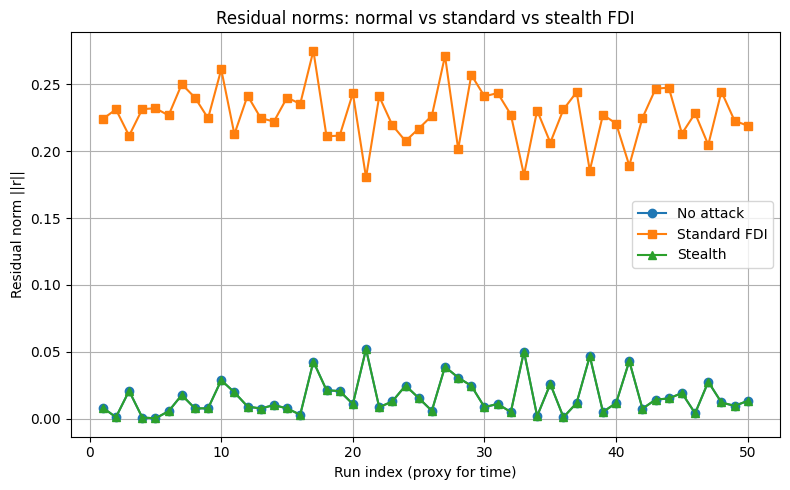

In [13]:
# 6.1 Residual norms over repeated runs

n_runs = 50
sigma = 0.02
attacked_indices = np.arange(H.shape[0])

resid_norms_no = []
resid_norms_standard = []
resid_norms_stealth = []

for k in range(n_runs):
    # Fresh noisy measurements each run
    z_no_k = simulate_measurements(H, x_true, sigma, rng)
    x_hat_no_k, _ = wls_estimate(H, z_no_k, sigma)
    r_no_k = compute_residuals(H, z_no_k, x_hat_no_k)

    z_standard_k = standard_FDIA(z_no_k, attacked_indices, shift=0.1)
    x_hat_standard_k, _ = wls_estimate(H, z_standard_k, sigma)
    r_standard_k = compute_residuals(H, z_standard_k, x_hat_standard_k)

    a_liu_k = stealth_FDIA(H, attacked_indices, alpha=0.05, rng=rng)
    z_stealth_k = z_no_k + a_liu_k
    x_hat_stealth_k, _ = wls_estimate(H, z_stealth_k, sigma)
    r_stealth_k = compute_residuals(H, z_stealth_k, x_hat_stealth_k)

    resid_norms_no.append(np.linalg.norm(r_no_k))
    resid_norms_standard.append(np.linalg.norm(r_standard_k))
    resid_norms_stealth.append(np.linalg.norm(r_stealth_k))

runs = np.arange(1, n_runs + 1)

plt.figure(figsize=(8, 5))
plt.plot(runs, resid_norms_no, marker="o", label="No attack")
plt.plot(runs, resid_norms_standard, marker="s", label="Standard FDI")
plt.plot(runs, resid_norms_stealth, marker="^", label="Stealth")
plt.xlabel("Run index (proxy for time)")
plt.ylabel("Residual norm ||r||")
plt.title("Residual norms: normal vs standard vs stealth FDI")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### 6.2 - New Plot 2 – State error vs attack magnitude

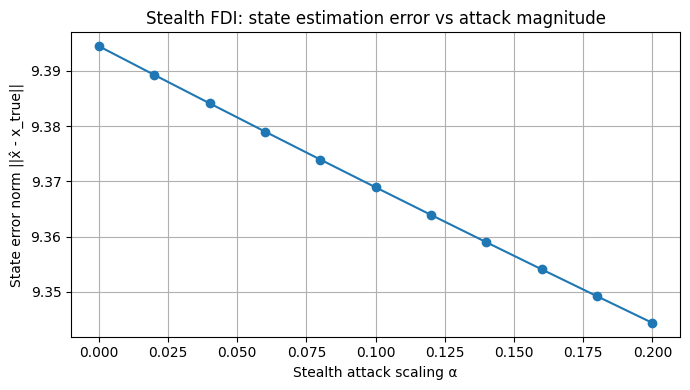

Residual norms for stealth FDI across α (should be ~constant):
[np.float64(0.01726938796999519), np.float64(0.017269387969995234), np.float64(0.017269387969995314), np.float64(0.01726938796999542), np.float64(0.017269387969995567), np.float64(0.01726938796999574), np.float64(0.01726938796999596), np.float64(0.017269387969996202), np.float64(0.01726938796999648), np.float64(0.017269387969996792), np.float64(0.01726938796999714)]
min = 0.01726938796999519 max = 0.01726938796999714


In [14]:
# Stealth FDI: state error vs attack magnitude (residual ~ constant)

attack_magnitudes = np.linspace(0.0, 0.2, 11)

error_norms_stealth = []

# Fix one noisy baseline and one stealth direction
z_no_base = simulate_measurements(H, x_true, sigma, rng)

n = H.shape[1]
c_dir = rng.standard_normal(n)
c_dir = c_dir / np.linalg.norm(c_dir)
a_base = H @ c_dir   # base stealth attack direction in measurement space

for alpha in attack_magnitudes:
    z_stealth_alpha = z_no_base + alpha * a_base

    x_hat_stealth_alpha, _ = wls_estimate(H, z_stealth_alpha, sigma)
    error_norms_stealth.append(np.linalg.norm(x_hat_stealth_alpha - x_true))

plt.figure(figsize=(7, 4))
plt.plot(attack_magnitudes, error_norms_stealth, marker="o")
plt.xlabel("Stealth attack scaling α")
plt.ylabel("State error norm ||x̂ - x_true||")
plt.title("Stealth FDI: state estimation error vs attack magnitude")
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional numeric check on residuals (kept out of the plot)
resid_norms_stealth = []
for alpha in attack_magnitudes:
    z_stealth_alpha = z_no_base + alpha * a_base
    x_hat_stealth_alpha, _ = wls_estimate(H, z_stealth_alpha, sigma)
    r_stealth_alpha = compute_residuals(H, z_stealth_alpha, x_hat_stealth_alpha)
    resid_norms_stealth.append(np.linalg.norm(r_stealth_alpha))

print("Residual norms for stealth FDI across α (should be ~constant):")
print(resid_norms_stealth)
print("min =", min(resid_norms_stealth), "max =", max(resid_norms_stealth))


In [15]:
print(resid_norms_stealth)
print("Min:", min(resid_norms_stealth))
print("Max:", max(resid_norms_stealth))
print("Range:", max(resid_norms_stealth)-min(resid_norms_stealth))

[np.float64(0.01726938796999519), np.float64(0.017269387969995234), np.float64(0.017269387969995314), np.float64(0.01726938796999542), np.float64(0.017269387969995567), np.float64(0.01726938796999574), np.float64(0.01726938796999596), np.float64(0.017269387969996202), np.float64(0.01726938796999648), np.float64(0.017269387969996792), np.float64(0.01726938796999714)]
Min: 0.01726938796999519
Max: 0.01726938796999714
Range: 1.949829186997931e-15


### 7 - Probabilistic state estimation (Kalman-style update)

In [16]:
def kalman_update(x_prior, P_prior, H, z, R, Q=None):
    """
    Single Kalman-filter update for static DC model:
        x_k = x_{k-1}
        z_k = H x_k + v_k

    Q: process noise covariance (small value to keep filter 'soft').
    """
    n = len(x_prior)
    if Q is None:
        Q = 1e-6 * np.eye(n)

    # Prediction (static state, so x_pred = x_prior)
    x_pred = x_prior
    P_pred = P_prior + Q

    # Innovation
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)
    y = z - H @ x_pred

    # Update
    x_post = x_pred + K @ y
    P_post = (np.eye(n) - K @ H) @ P_pred

    return x_post, P_post


# Build measurement covariance once
R_kf = (sigma ** 2) * np.eye(H.shape[0])

# Vague prior
n = len(x_true)
x_prior = np.zeros(n)
P_prior = 10.0 * np.eye(n)

# Compare no-attack vs stealth for WLS and Kalman
x_hat_wls_no, _ = wls_estimate(H, z_no, sigma)
x_hat_kf_no, P_post_no = kalman_update(x_prior, P_prior, H, z_no, R_kf)

x_hat_wls_stealth, _ = wls_estimate(H, z_stealth, sigma)
x_hat_kf_stealth, P_post_stealth = kalman_update(x_prior, P_prior, H, z_stealth, R_kf)

print("No attack:")
print("  ||x_wls - x_true|| =", np.linalg.norm(x_hat_wls_no - x_true))
print("  ||x_kf  - x_true|| =", np.linalg.norm(x_hat_kf_no  - x_true))

print("\nStealth attack:")
print("  ||x_wls - x_true|| =", np.linalg.norm(x_hat_wls_stealth - x_true))
print("  ||x_kf  - x_true|| =", np.linalg.norm(x_hat_kf_stealth  - x_true))


No attack:
  ||x_wls - x_true|| = 7.959912139192355
  ||x_kf  - x_true|| = 4.1321959146134875

Stealth attack:
  ||x_wls - x_true|| = 7.9718585832464575
  ||x_kf  - x_true|| = 4.144285667545889


The system operator sees no anomaly in the residual, but the estimated state is corrupted.
I.e. stealth FDIAs can arbitrarily change the estimated system state while keeping the classic residual based detector blind. Motivating the need for ML-based, temporal, or hybrid anomaly detection methods. 

IEEE-9 test case results tell us that it is easier to destabalise, residual based detection fails just as poorly, and stealth FDIA cause greater damage compared to IEEE-14.